In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

COLOR_PEERS = '#5B8DB8'
COLOR_BRA   = '#009C3B'
COLOR_RED   = '#c0392b'

In [60]:
df = pd.read_csv('Tourism Quantity Data Analyzed.csv')
df.head()

,País,Sigla,Continente,Region,IncomeGroup,Ano,Population,Arrivals,Receipts,Expenditures,...,Gasto_Turista,Receita_menos_Despesas,Receita_Despesa,Turista_Habitante,Dependencia_Media,Crescimento_Arrivals,Crescimento_Receipts,Cresc_Acumulado_Arrivals,Volatilidade_Arrivals,Perfil_Turistico
0,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2004,3026939.0,645000.0,7.560000e+08,6.690000e+08,...,1037.209302,87000000.0,1.130045,0.213087,53.620667,NaN,NaN,818.914729,1.694995e+06,Turismo de alto valor
1,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2005,3011487.0,748000.0,8.800000e+08,8.080000e+08,...,1080.213904,72000000.0,1.089109,0.248382,53.620667,0.159690,0.164021,818.914729,1.694995e+06,Turismo de alto valor
2,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2006,2992547.0,937000.0,1.057000e+09,9.890000e+08,...,1055.496265,68000000.0,1.068756,0.313111,53.620667,0.252674,0.201136,818.914729,1.694995e+06,Turismo de alto valor
3,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2007,2970017.0,1127000.0,1.479000e+09,1.331000e+09,...,1181.011535,148000000.0,1.111195,0.379459,53.620667,0.202775,0.399243,818.914729,1.694995e+06,Perfil misto
4,Albania,ALB,EU,Europe & Central Asia,Upper middle income,2008,2947314.0,1420000.0,1.850000e+09,1.644000e+09,...,1157.746479,206000000.0,1.125304,0.481795,53.620667,0.259982,0.250845,818.914729,1.694995e+06,Perfil misto


# 1.2 Eficiência, Crescimento e Dependência Econômica

**Pergunta orientadora:** Mais turistas significam mais receita e melhor desempenho turístico?

## Teste 3: Predomínio de superávit ou déficit turístico

- **H0:** Há equilíbrio entre países com superávit e países com déficit turístico.
- **H1:** Há predominância clara de superávit ou de déficit turístico.

**Método:** Teste binomial bicaudal com p0 = 0,5 (hipótese de equilíbrio), α = 0,05. Unidade de análise: último ano disponível por país, excluindo territórios.

In [61]:
from scipy import stats
from matplotlib.patches import Patch

last_all = df.sort_values('Ano').groupby('Sigla').last().reset_index()
last_all = last_all[~last_all['Is_Territory']].copy()

last_all['Superavit'] = last_all['Receita_menos_Despesas'] > 0

n_super = last_all['Superavit'].sum()
n_defic = (~last_all['Superavit']).sum()
n_total = n_super + n_defic

binom_result = stats.binomtest(int(n_super), int(n_total), p=0.5, alternative='two-sided')
p_binom = binom_result.pvalue

print("=" * 50)
print("TESTE 3 - PREDOMÍNIO DE SUPERÁVIT OU DÉFICIT")
print("=" * 50)
print(f"Países com SUPERÁVIT : {n_super:>5} ({n_super/n_total*100:.1f}%)")
print(f"Países com DÉFICIT   : {n_defic:>5} ({n_defic/n_total*100:.1f}%)")
print(f"Total de países      : {n_total:>5}")
print(f"Proporção superávit  : {n_super/n_total:.3f}")
print(f"p-value (binomial)   : {p_binom:.6f}")
print()
if p_binom > 0.05:
    print("H0 NÃO REJEITADA - sem predominância significativa (p > 0,05)")
else:
    print("H0 REJEITADA - há predominância estatisticamente significativa de superávit (p ≤ 0,05)")

TESTE 3 - PREDOMÍNIO DE SUPERÁVIT OU DÉFICIT
Países com SUPERÁVIT :    99 (61.5%)
Países com DÉFICIT   :    62 (38.5%)
Total de países      :   161
Proporção superávit  : 0.615
p-value (binomial)   : 0.004403

H0 REJEITADA - há predominância estatisticamente significativa de superávit (p ≤ 0,05)


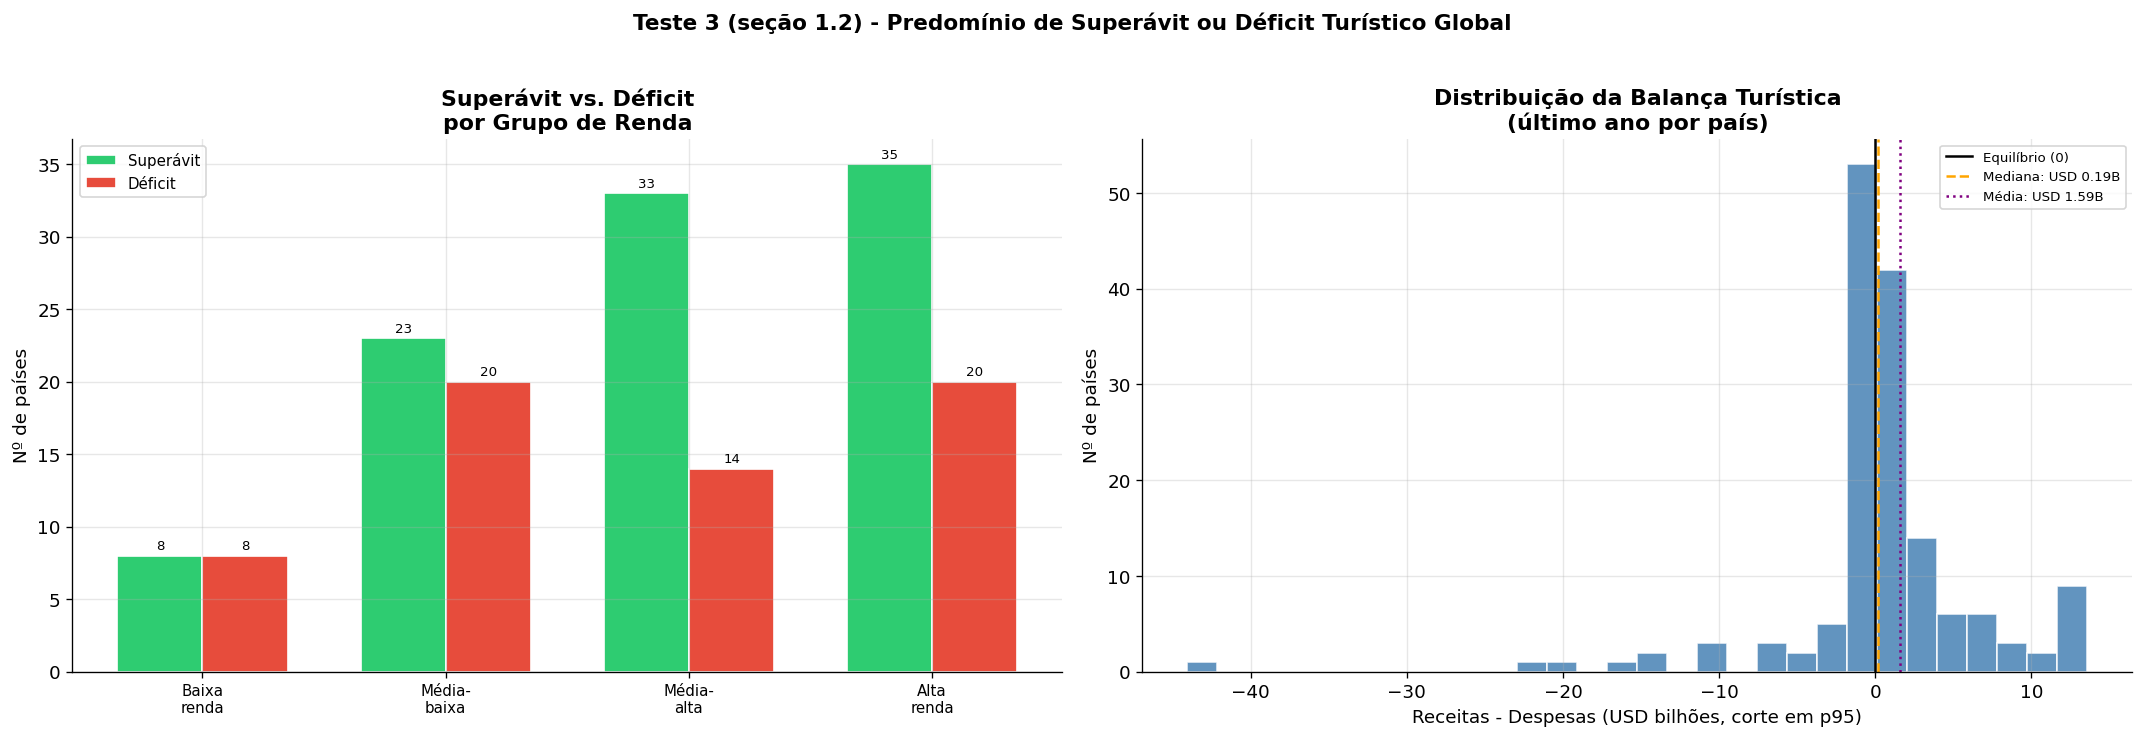


61.5% dos países registraram superávit turístico no último ano.
A mediana positiva indica que a maioria dos países recebe mais do que gasta,
mas a distribuição tem cauda longa à direita (poucos países concentram grandes superávits).


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ig_stats = (
    last_all.groupby('IncomeGroup')['Superavit']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Superavit', 'count': 'Total'})
    .assign(Deficit=lambda x: x['Total'] - x['Superavit'])
    .reset_index()
)
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
ig_stats = ig_stats.set_index('IncomeGroup').reindex(income_order).reset_index()

x = np.arange(len(ig_stats))
w = 0.35
bars_s = axes[0].bar(x - w/2, ig_stats['Superavit'], w, color='#2ecc71', edgecolor='white', label='Superávit')
bars_d = axes[0].bar(x + w/2, ig_stats['Deficit'],   w, color='#e74c3c', edgecolor='white', label='Déficit')
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ['Baixa\nrenda', 'Média-\nbaixa', 'Média-\nalta', 'Alta\nrenda'],
    fontsize=9
)
axes[0].bar_label(bars_s, padding=2, fontsize=8)
axes[0].bar_label(bars_d, padding=2, fontsize=8)
axes[0].set_ylabel('Nº de países')
axes[0].set_title('Superávit vs. Déficit\npor Grupo de Renda', fontweight='bold')
axes[0].legend(fontsize=9)

# grafico 2
bal = last_all['Receita_menos_Despesas'].dropna()
bal_bi = bal / 1e9
clip_val = bal_bi.quantile(0.95)
axes[1].hist(
    bal_bi.clip(upper=clip_val), bins=30,
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='-', label='Equilíbrio (0)')
axes[1].axvline(bal_bi.median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana: USD {bal_bi.median():.2f}B')
axes[1].axvline(bal_bi.mean(), color='purple', linestyle=':', linewidth=1.5,
                label=f'Média: USD {bal_bi.mean():.2f}B')
axes[1].set_xlabel('Receitas - Despesas (USD bilhões, corte em p95)')
axes[1].set_ylabel('Nº de países')
axes[1].set_title('Distribuição da Balança Turística\n(último ano por país)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle(
    'Teste 3 (seção 1.2) - Predomínio de Superávit ou Déficit Turístico Global',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('sec12_teste3_balanca_global.png', bbox_inches='tight')
plt.show()

print(f"\n{n_super/n_total*100:.1f}% dos países registraram superávit turístico no último ano.")
print("A mediana positiva indica que a maioria dos países recebe mais do que gasta,")
print("mas a distribuição tem cauda longa à direita (poucos países concentram grandes superávits).")

### Conclusão: Teste 3 (seção 1.2)

**H0 rejeitada** (p = 0,004 ≤ 0,05).

O teste binomial rejeita a hipótese de equilíbrio: 61,5% dos países apresentaram superávit turístico no último ano analisado, proporção significativamente maior do que os 50% esperados sob H0. Superávit predomina em todos os grupos de renda, sendo mais acentuado nos países de renda média-alta (70,2%) e alta (63,6%). A distribuição da balança é assimétrica à direita, com média e mediana positivas, confirmando que o turismo receptor supera o emissor na maioria dos países do mundo.

# 1.3 Brasil no Turismo Internacional

**Pergunta orientadora:** O Brasil tem desempenho turístico parecido, melhor ou pior que países comparáveis?

### Grupo comparável
Utilizamos países de renda média-alta (Upper Middle Income) segundo classificação do Banco Mundial(mesma faixa do Brasil) com dados de chegadas disponíveis (n = 47 países, último ano disponível = 2018).

In [63]:
last = df.sort_values('Ano').groupby('Sigla').last().reset_index()

peers = last[(last['IncomeGroup'] == 'Upper middle income') & last['Arrivals'].notna()].copy()

bra   = peers[peers['Sigla'] == 'BRA'].iloc[0]
others = peers[peers['Sigla'] != 'BRA'].copy()

print(f"Países no grupo comparável: {len(peers)}")
print(f"Brasil - Arrivals: {bra['Arrivals']:,.0f}")
print(f"Brasil - Receita por turista: USD {bra['Receita_Turista']:,.2f}")
print(f"\nPaíses comparáveis:")
print(peers['País'].sort_values().values)

Países no grupo comparável: 47
Brasil - Arrivals: 6,621,000
Brasil - Receita por turista: USD 955.14

Países comparáveis:
['Albania' 'Algeria' 'Argentina' 'Armenia' 'Azerbaijan' 'Belarus' 'Belize'
 'Bosnia and Herzegovina' 'Brazil' 'Cabo Verde' 'China' 'Colombia' 'Cuba'
 'Dominica' 'Dominican Republic' 'Ecuador' 'El Salvador' 'Fiji' 'Georgia'
 'Grenada' 'Guatemala' 'Indonesia' 'Iran' 'Iraq' 'Jamaica' 'Kazakhstan'
 'Malaysia' 'Maldives' 'Marshall Islands' 'Mauritius' 'Mexico' 'Moldova'
 'Mongolia' 'Montenegro' 'North Macedonia' 'Paraguay' 'Peru' 'Samoa'
 'Serbia' 'South Africa' 'St. Lucia' 'Suriname' 'Thailand' 'Tonga'
 'Turkiye' 'Tuvalu' 'Ukraine']


## Teste 1: Brasil recebe menos turistas que países comparáveis?

- **H0:** O Brasil recebe um número de turistas *semelhante* ao dos países comparáveis.
- **H1:** O Brasil recebe um número de turistas *diferente* dos países comparáveis.

**Método:** teste t unilateral (uma amostra) com α = 0,05. O valor do Brasil é comparado à distribuição dos peers.

In [64]:
arr_peers = others['Arrivals'].dropna()
t1, p1 = stats.ttest_1samp(arr_peers, bra['Arrivals'])
pct1 = (arr_peers < bra['Arrivals']).mean() * 100

print("=" * 50)
print("TESTE 1 — CHEGADAS DE TURISTAS (Arrivals)")
print("=" * 50)
print(f"Brasil              : {bra['Arrivals']:>15,.0f} turistas")
print(f"Média dos peers     : {arr_peers.mean():>15,.0f} turistas")
print(f"Mediana dos peers   : {arr_peers.median():>15,.0f} turistas")
print(f"Percentil do Brasil : {pct1:>14.1f}°")
print(f"t-statistic         : {t1:>15.3f}")
print(f"p-value             : {p1:>15.4f}")
print()
if p1 > 0.05:
    print("H0 NÃO REJEITADA - sem diferença estatisticamente significativa (p > 0,05)")
else:
    print("H0 REJEITADA - diferença estatisticamente significativa (p ≤ 0,05)")

TESTE 1 — CHEGADAS DE TURISTAS (Arrivals)
Brasil              :       6,621,000 turistas
Média dos peers     :      11,287,637 turistas
Mediana dos peers   :       2,535,500 turistas
Percentil do Brasil :           69.6°
t-statistic         :           1.149
p-value             :          0.2567

H0 NÃO REJEITADA - sem diferença estatisticamente significativa (p > 0,05)


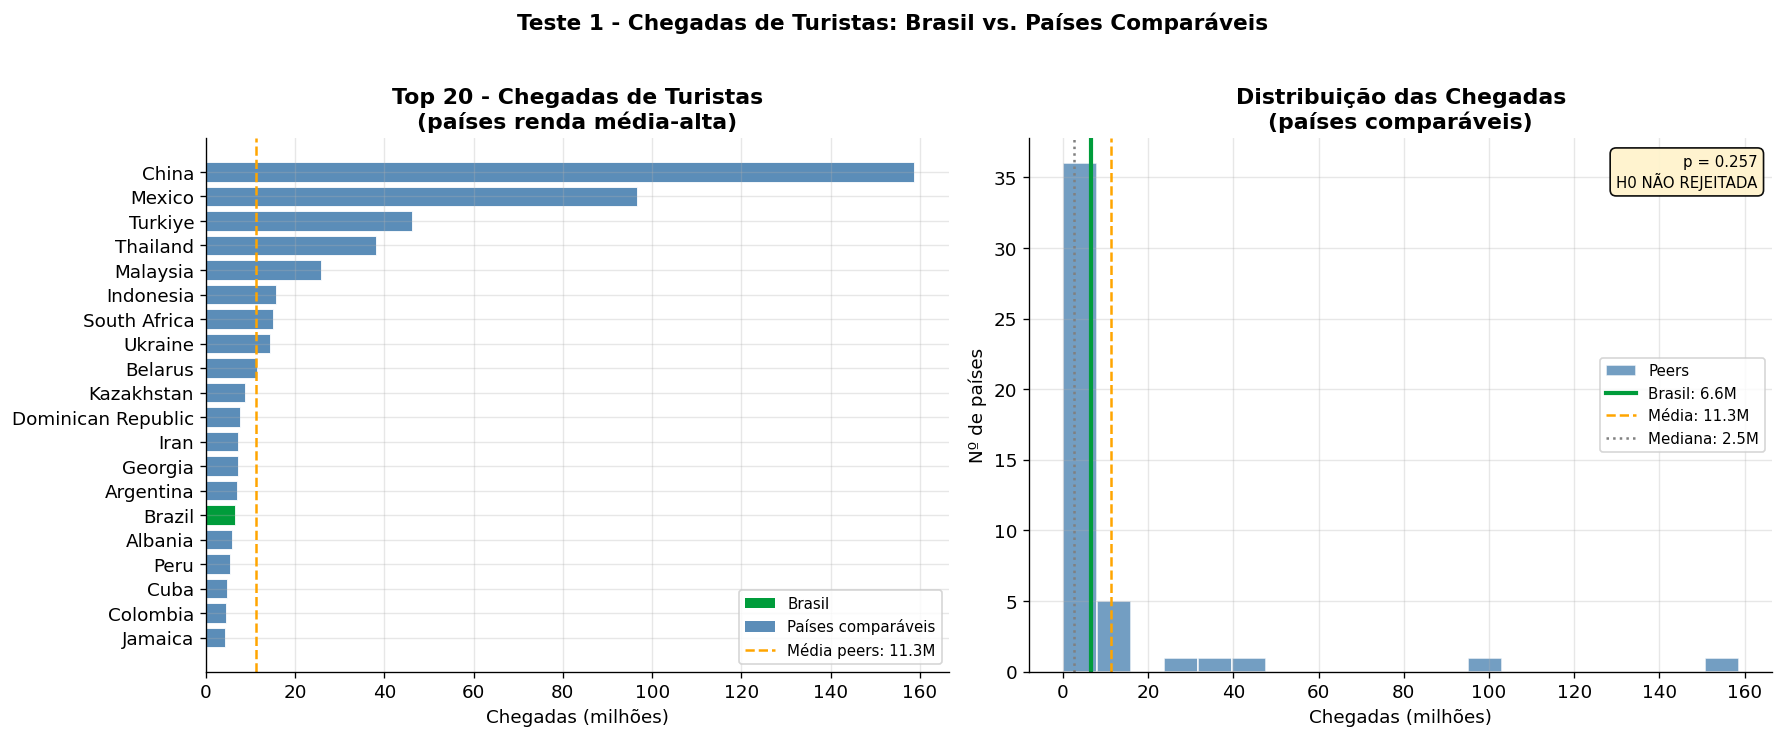


A distribuição é assimétrica à direita - China e México puxam a média.
O Brasil está no percentil 69,6°, acima da mediana do grupo.


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top20 = peers.sort_values('Arrivals', ascending=False).head(20).copy()
colors_bar = [COLOR_BRA if s == 'BRA' else COLOR_PEERS for s in top20['Sigla']]
axes[0].barh(
    top20['País'][::-1], top20['Arrivals'][::-1] / 1e6,
    color=colors_bar[::-1], edgecolor='white', linewidth=0.5
)
axes[0].axvline(
    arr_peers.mean() / 1e6, color='orange', linestyle='--', linewidth=1.5,
    label=f'Média peers: {arr_peers.mean()/1e6:.1f}M'
)
axes[0].set_xlabel('Chegadas (milhões)')
axes[0].set_title('Top 20 - Chegadas de Turistas\n(países renda média-alta)', fontweight='bold')
axes[0].legend(fontsize=9)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=COLOR_BRA, label='Brasil'),
    Patch(facecolor=COLOR_PEERS, label='Países comparáveis'),
]
axes[0].legend(handles=legend_els + [axes[0].lines[0]], fontsize=9)

# outro gráfico
axes[1].hist(
    arr_peers / 1e6, bins=20,
    color=COLOR_PEERS, edgecolor='white', alpha=0.85, label='Peers'
)
axes[1].axvline(
    bra['Arrivals'] / 1e6, color=COLOR_BRA, linewidth=2.5,
    label=f"Brasil: {bra['Arrivals']/1e6:.1f}M"
)
axes[1].axvline(
    arr_peers.mean() / 1e6, color='orange', linestyle='--', linewidth=1.5,
    label=f"Média: {arr_peers.mean()/1e6:.1f}M"
)
axes[1].axvline(
    arr_peers.median() / 1e6, color='gray', linestyle=':', linewidth=1.5,
    label=f"Mediana: {arr_peers.median()/1e6:.1f}M"
)
axes[1].set_xlabel('Chegadas (milhões)')
axes[1].set_ylabel('Nº de países')
axes[1].set_title('Distribuição das Chegadas\n(países comparáveis)', fontweight='bold')
axes[1].legend(fontsize=9)

verdict = 'H0 NÃO REJEITADA' if p1 > 0.05 else 'H0 REJEITADA'
axes[1].text(
    0.98, 0.97, f"p = {p1:.3f}\n{verdict}",
    transform=axes[1].transAxes, fontsize=9, ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', alpha=0.95)
)

plt.suptitle('Teste 1 - Chegadas de Turistas: Brasil vs. Países Comparáveis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('teste1_arrivals.png', bbox_inches='tight')
plt.show()

print("\nA distribuição é assimétrica à direita - China e México puxam a média.")
print("O Brasil está no percentil 69,6°, acima da mediana do grupo.")

### Conclusão: Teste 1

**H0 não rejeitada** (p = 0,257 > 0,05).

O volume de chegadas do Brasil (6,6M) não é estatisticamente diferente do grupo de países comparáveis. O Brasil está no 69,6° percentil, acima da mediana de 2,5M mas abaixo da média inflacionada por gigantes como China (158M) e México (96M). Não há evidência de subdesempenho em volume de chegadas.


## Teste 2: Brasil gera menos receita por turista?

- **H0:** A receita por turista do Brasil é semelhante à dos países comparáveis.
- **H1:** A receita por turista do Brasil é diferente da dos países comparáveis.

**Método:** teste t unilateral (uma amostra) com α = 0,05.

In [66]:
rt_peers = others['Receita_Turista'].dropna()
t2, p2 = stats.ttest_1samp(rt_peers, bra['Receita_Turista'])
pct2 = (rt_peers < bra['Receita_Turista']).mean() * 100

print("=" * 50)
print("TESTE 2 - RECEITA POR TURISTA")
print("=" * 50)
print(f"Brasil              : USD {bra['Receita_Turista']:>12,.2f}")
print(f"Média dos peers     : USD {rt_peers.mean():>12,.2f}")
print(f"Mediana dos peers   : USD {rt_peers.median():>12,.2f}")
print(f"Percentil do Brasil : {pct2:>14.1f}°")
print(f"t-statistic         : {t2:>15.3f}")
print(f"p-value             : {p2:>15.4f}")
print()
if p2 > 0.05:
    print("H0 NÃO REJEITADA - sem diferença estatisticamente significativa (p > 0,05)")
else:
    print("H0 REJEITADA - diferença estatisticamente significativa (p ≤ 0,05)")

TESTE 2 - RECEITA POR TURISTA
Brasil              : USD       955.14
Média dos peers     : USD       914.66
Mediana dos peers   : USD       822.03
Percentil do Brasil :           64.4°
t-statistic         :          -0.407
p-value             :          0.6862

H0 NÃO REJEITADA - sem diferença estatisticamente significativa (p > 0,05)


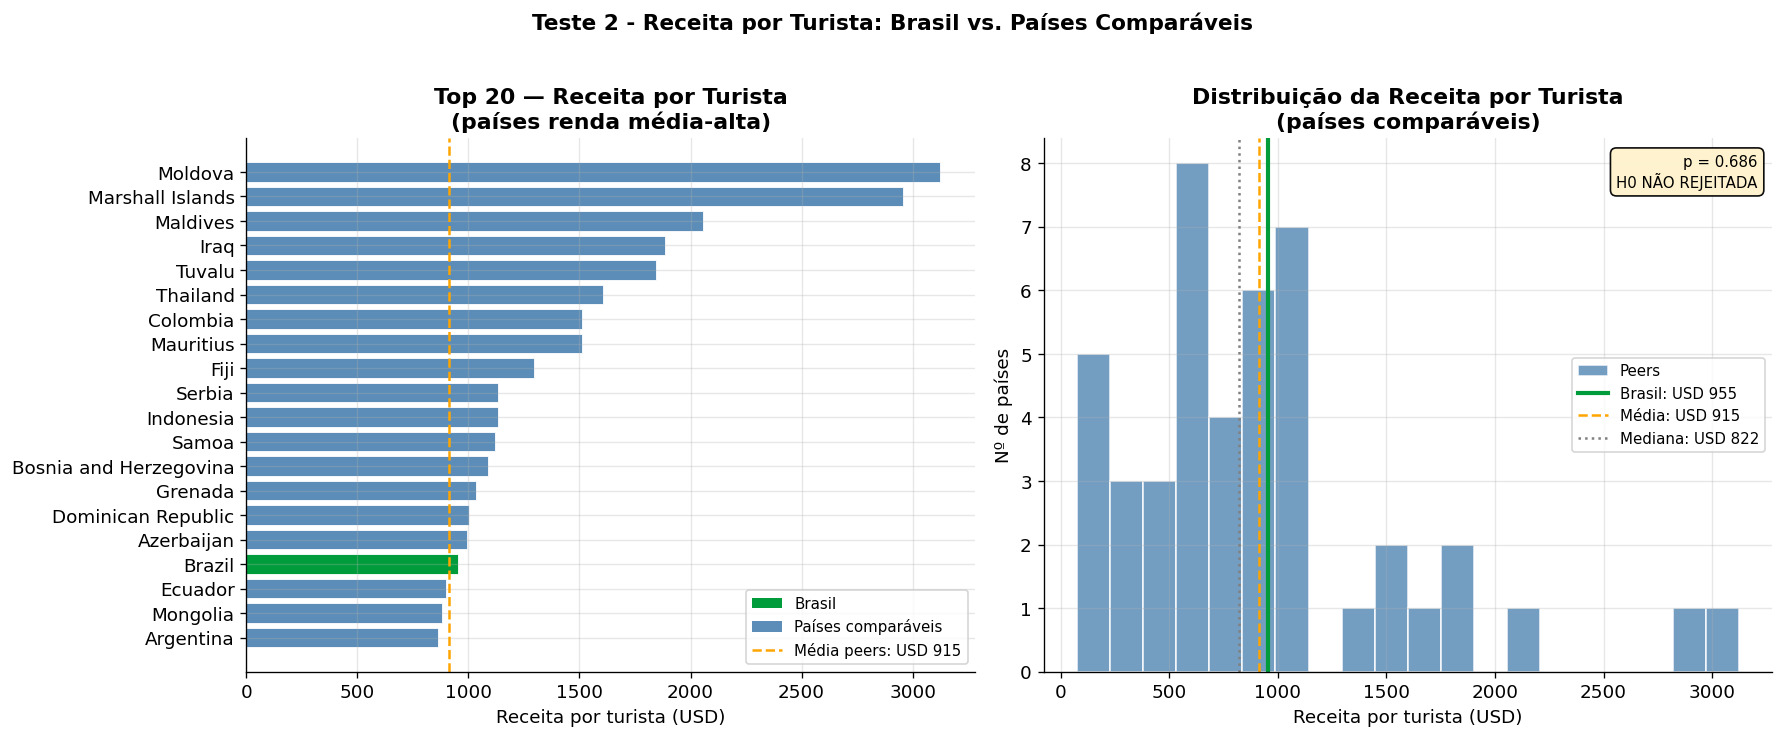


Brasil (USD 955) está acima da mediana dos peers (USD 822)
e praticamente empatado com a média (USD 915).


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top20_rt = peers.dropna(subset=['Receita_Turista']).sort_values('Receita_Turista', ascending=False).head(20)
colors_rt = [COLOR_BRA if s == 'BRA' else COLOR_PEERS for s in top20_rt['Sigla']]
axes[0].barh(
    top20_rt['País'][::-1], top20_rt['Receita_Turista'][::-1],
    color=colors_rt[::-1], edgecolor='white', linewidth=0.5
)
axes[0].axvline(
    rt_peers.mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f'Média peers: USD {rt_peers.mean():,.0f}'
)
axes[0].set_xlabel('Receita por turista (USD)')
axes[0].set_title('Top 20 — Receita por Turista\n(países renda média-alta)', fontweight='bold')
legend_els2 = [
    Patch(facecolor=COLOR_BRA, label='Brasil'),
    Patch(facecolor=COLOR_PEERS, label='Países comparáveis'),
]
axes[0].legend(handles=legend_els2 + [axes[0].lines[0]], fontsize=9)

# gráfico dois
axes[1].hist(
    rt_peers, bins=20,
    color=COLOR_PEERS, edgecolor='white', alpha=0.85, label='Peers'
)
axes[1].axvline(
    bra['Receita_Turista'], color=COLOR_BRA, linewidth=2.5,
    label=f"Brasil: USD {bra['Receita_Turista']:,.0f}"
)
axes[1].axvline(
    rt_peers.mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f"Média: USD {rt_peers.mean():,.0f}"
)
axes[1].axvline(
    rt_peers.median(), color='gray', linestyle=':', linewidth=1.5,
    label=f"Mediana: USD {rt_peers.median():,.0f}"
)
axes[1].set_xlabel('Receita por turista (USD)')
axes[1].set_ylabel('Nº de países')
axes[1].set_title('Distribuição da Receita por Turista\n(países comparáveis)', fontweight='bold')
axes[1].legend(fontsize=9)

verdict2_txt = 'H0 NÃO REJEITADA' if p2 > 0.05 else 'H0 REJEITADA'
axes[1].text(
    0.98, 0.97, f"p = {p2:.3f}\n{verdict2_txt}",
    transform=axes[1].transAxes, fontsize=9, ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', alpha=0.95)
)

plt.suptitle('Teste 2 - Receita por Turista: Brasil vs. Países Comparáveis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('teste2_receita_turista.png', bbox_inches='tight')
plt.show()

print("\nBrasil (USD 955) está acima da mediana dos peers (USD 822)")
print("e praticamente empatado com a média (USD 915).")

### Conclusão: Teste 2

**H0 não rejeitada** (p = 0,686 > 0,05).

A receita por turista do Brasil (USD 955) está no 64,4° percentil do grupo comparável, acima da mediana (USD 822) e praticamente igual à média (USD 915). Não há evidência estatística de que o Brasil gera menos valor por visitante do que seus pares.

## Teste 3: Brasil apresenta déficit turístico recorrente?

- **H0:** A balança turística do Brasil é equilibrada no período analisado.
- **H1:** A balança turística do Brasil apresenta superávit ou déficit recorrente.

**Método:** teste t de uma amostra com μ₀ = 0 (hipótese de equilíbrio), α = 0,05. Série temporal: 2004–2018.

In [68]:
bra_bal = df[df['Sigla'] == 'BRA'][['Ano', 'Receita_menos_Despesas']].dropna().copy()
bra_bal['val_bi'] = bra_bal['Receita_menos_Despesas'] / 1e9

t3, p3 = stats.ttest_1samp(bra_bal['Receita_menos_Despesas'], 0)

print("=" * 50)
print("TESTE 3 - BALANÇA TURÍSTICA DO BRASIL (2004–2018)")
print("=" * 50)
print(f"Anos analisados     : {len(bra_bal)}")
print(f"Anos com déficit    : {(bra_bal['Receita_menos_Despesas'] < 0).sum()} de {len(bra_bal)}")
print(f"Média               : USD {bra_bal['Receita_menos_Despesas'].mean()/1e9:,.1f}B")
print(f"Mínimo (pior ano)   : USD {bra_bal['Receita_menos_Despesas'].min()/1e9:,.1f}B ({bra_bal.loc[bra_bal['Receita_menos_Despesas'].idxmin(), 'Ano']})")
print(f"Máximo (melhor ano) : USD {bra_bal['Receita_menos_Despesas'].max()/1e9:,.1f}B ({bra_bal.loc[bra_bal['Receita_menos_Despesas'].idxmax(), 'Ano']})")
print(f"t-statistic         : {t3:.3f}")
print(f"p-value             : {p3:.6f}")
print()
if p3 > 0.05:
    print("H0 NÃO REJEITADA - balança não difere significativamente de zero")
else:
    print("H0 REJEITADA - déficit recorrente e estatisticamente significativo (p < 0,001)")

TESTE 3 - BALANÇA TURÍSTICA DO BRASIL (2004–2018)
Anos analisados     : 15
Anos com déficit    : 15 de 15
Média               : USD -11.9B
Mínimo (pior ano)   : USD -22.6B (2014)
Máximo (melhor ano) : USD -0.4B (2004)
t-statistic         : -6.161
p-value             : 0.000025

H0 REJEITADA - déficit recorrente e estatisticamente significativo (p < 0,001)


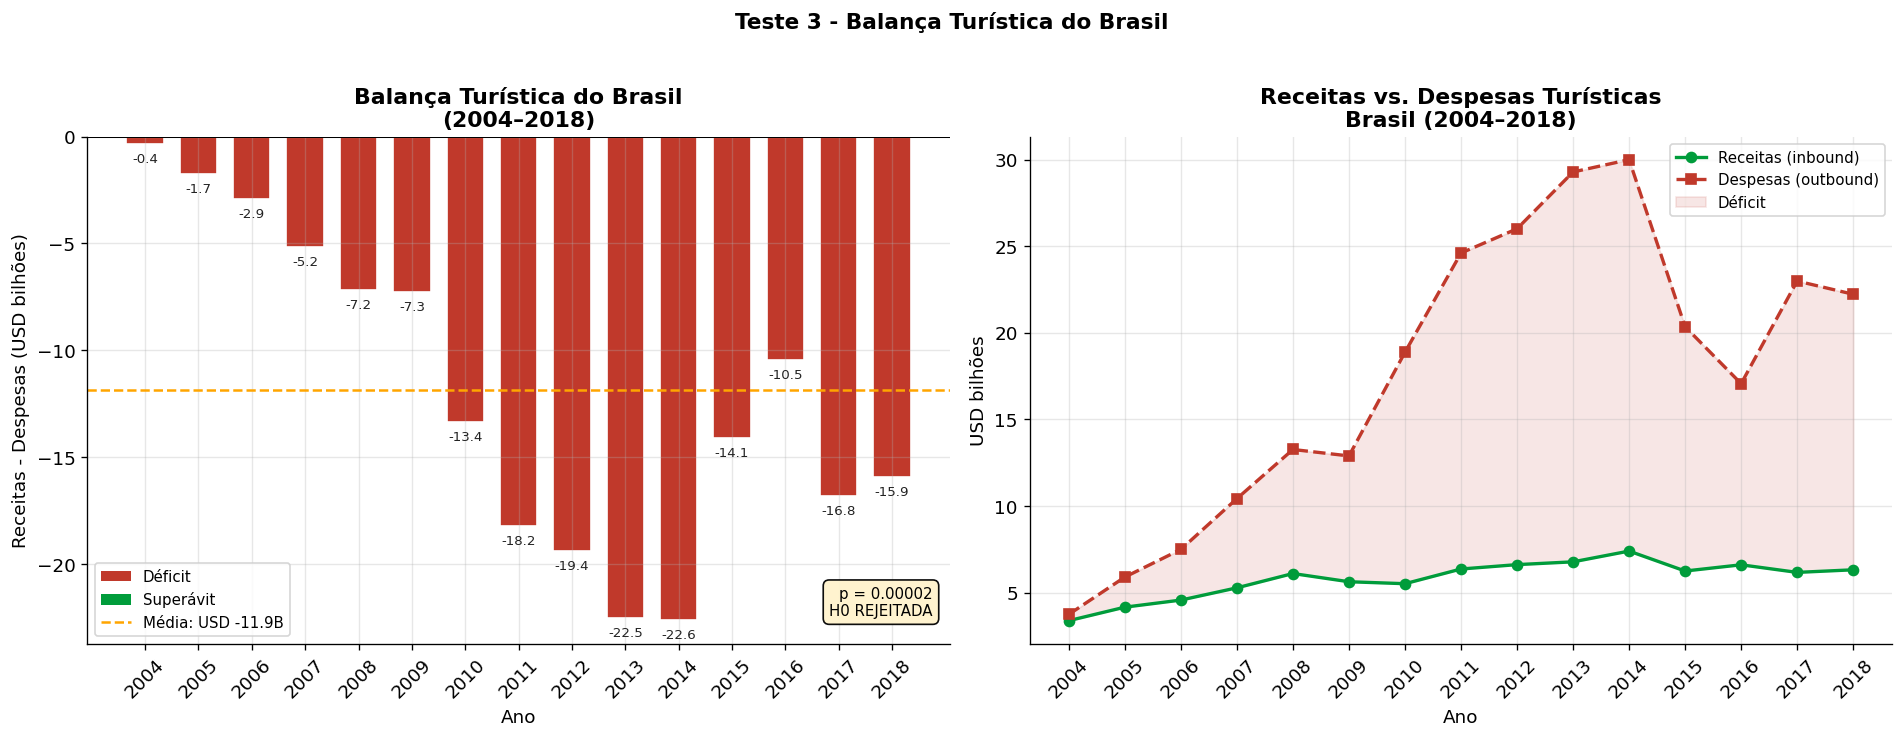


As despesas cresceram muito mais rápido que as receitas a partir de 2010,
refletindo o aumento do turismo emissor brasileiro durante o boom econômico.


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = [COLOR_RED if v < 0 else COLOR_BRA for v in bra_bal['val_bi']]
bars = axes[0].bar(bra_bal['Ano'], bra_bal['val_bi'], color=bar_colors, edgecolor='white', width=0.7)
axes[0].axhline(0, color='black', linewidth=1.2)
axes[0].axhline(
    bra_bal['val_bi'].mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f"Média: USD {bra_bal['val_bi'].mean():.1f}B"
)
for bar, val in zip(bars, bra_bal['val_bi']):
    ypos = val + 0.3 if val >= 0 else val - 1.0
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, ypos,
        f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='#222'
    )
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Receitas - Despesas (USD bilhões)')
axes[0].set_title('Balança Turística do Brasil\n(2004–2018)', fontweight='bold')
axes[0].set_xticks(bra_bal['Ano'])
axes[0].tick_params(axis='x', rotation=45)
legend_els3 = [
    Patch(facecolor=COLOR_RED, label='Déficit'),
    Patch(facecolor=COLOR_BRA, label='Superávit'),
]
axes[0].legend(handles=legend_els3 + [axes[0].lines[1]], fontsize=9)

verdict3_txt = 'H0 NÃO REJEITADA' if p3 > 0.05 else 'H0 REJEITADA'
axes[0].text(
    0.98, 0.05, f"p = {p3:.5f}\n{verdict3_txt}",
    transform=axes[0].transAxes, fontsize=9, ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', alpha=0.95)
)

# gráfico dois
bra_full = df[df['Sigla'] == 'BRA'][['Ano', 'Receipts', 'Expenditures']].dropna().copy()
axes[1].plot(bra_full['Ano'], bra_full['Receipts'] / 1e9, marker='o',
             color=COLOR_BRA, linewidth=2, label='Receitas (inbound)')
axes[1].plot(bra_full['Ano'], bra_full['Expenditures'] / 1e9, marker='s',
             color=COLOR_RED, linewidth=2, linestyle='--', label='Despesas (outbound)')
axes[1].fill_between(
    bra_full['Ano'],
    bra_full['Receipts'] / 1e9,
    bra_full['Expenditures'] / 1e9,
    alpha=0.12, color=COLOR_RED, label='Déficit'
)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('USD bilhões')
axes[1].set_title('Receitas vs. Despesas Turísticas\nBrasil (2004–2018)', fontweight='bold')
axes[1].set_xticks(bra_full['Ano'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

plt.suptitle('Teste 3 - Balança Turística do Brasil',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('teste3_balanca.png', bbox_inches='tight')
plt.show()

print("\nAs despesas cresceram muito mais rápido que as receitas a partir de 2010,")
print("refletindo o aumento do turismo emissor brasileiro durante o boom econômico.")

### Conclusão: Teste 3

**H0 rejeitada** (p < 0,001).

O Brasil registrou déficit turístico em todos os 15 anos do período (2004–2018), com média de −USD 11,9B/ano. O déficit se aprofundou significativamente entre 2010 e 2014, impulsionado pelo crescimento acelerado das despesas dos brasileiros no exterior durante o boom econômico. O teste t confirma que a balança não é equilibrada, o déficit é recorrente e estatisticamente robusto.